In [4]:
from networkx.readwrite import json_graph
import json
import re
from collections import defaultdict

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [1]:
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [nltk]2/3 [nltk]]


In [2]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = json_graph.node_link_graph(data)

In [6]:
texts = defaultdict(list)

for u, v, d in G.edges(data=True):
    vote = d.get("vote")
    text = d.get("text", "")
    
    if text:
        texts[vote].append(text)

print("Positive:", len(texts[1]))
print("Negative:", len(texts[-1]))
print("Neutral:", len(texts[0]))

Positive: 132870
Negative: 38495
Neutral: 11367


In [10]:
import re

def clean_wiki_text(text):
    text = text.lower()

    # remove wiki formatting
    text = re.sub(r"'+", "", text)

    # handle wiki links [[A|B]] → B
    text = re.sub(r"\[\[[^|\]]*\|([^\]]+)\]\]", r"\1", text)
    text = re.sub(r"\[\[([^\]]+)\]\]", r"\1", text)

    # remove URLs
    text = re.sub(r"http\S+", "", text)

    # remove non-letters
    text = re.sub(r"[^a-z\s]", " ", text)

    # split into words
    words = text.split()

    # 🚨 THIS is where stopwords are actually applied
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

In [11]:
positive_text = clean_wiki_text(" ".join(texts[1]))
negative_text = clean_wiki_text(" ".join(texts[-1]))
neutral_text  = clean_wiki_text(" ".join(texts[0]))

In [13]:
def make_wordcloud(text, title):
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        collocations=False  # avoids duplicate phrases
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

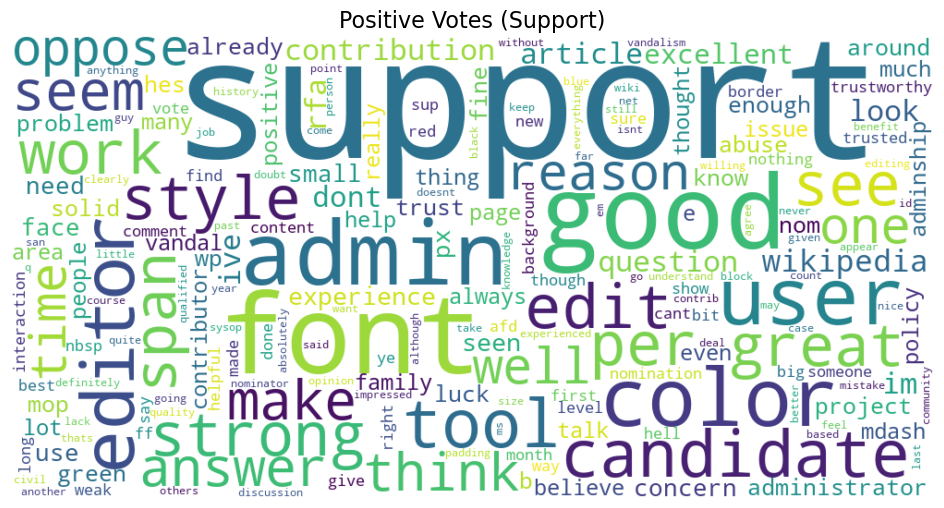

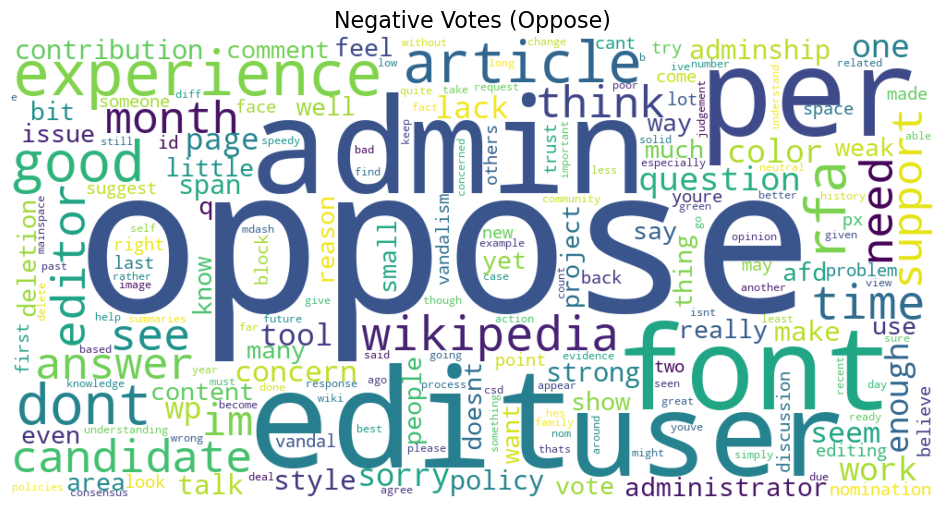

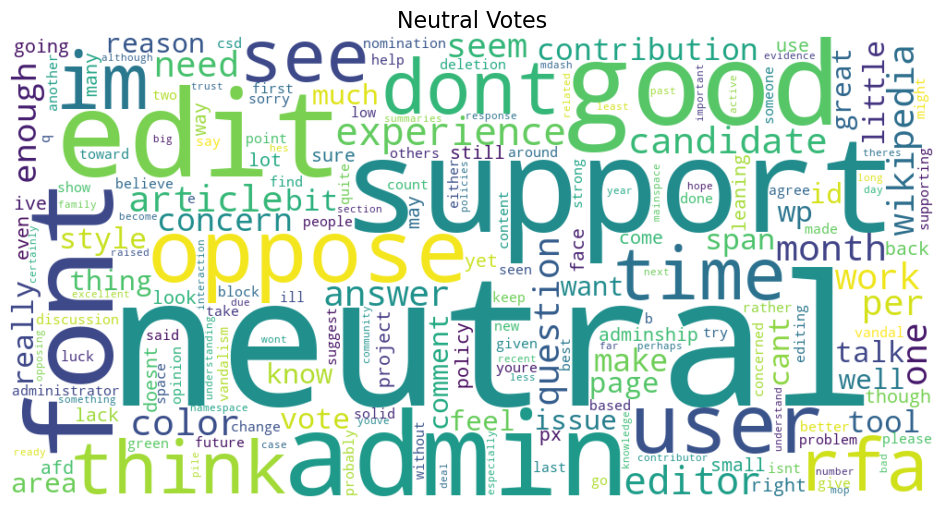

In [14]:
make_wordcloud(positive_text, "Positive Votes (Support)")
make_wordcloud(negative_text, "Negative Votes (Oppose)")
make_wordcloud(neutral_text, "Neutral Votes")